# Manipulating tensor

# Covered Topic :

 Device

 Manipulating Tensor

 Matrix Multiplication

 Finding the min , max , mean and sum

 Reshaping , viewing , and stacking


In [12]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print(torch.__version__)

2.11.0+cpu


# Device

In PyTorch, device means where a tensor or model is stored and where its computations are performed.

The two devices you'll use most often are:

CPU → Central Processing Unit

GPU → Graphics Processing Unit

**1. CPU**

In [1]:
import torch

x = torch.tensor([1, 2, 3])

print(x.device)

cpu


**2. GPU (CUDA) ⭐**

In [3]:
x = torch.tensor([1,2,3]).to("cuda")

print(x.device)

AssertionError: Torch not compiled with CUDA enabled

## Check Whether GPU is available

In [4]:
print(torch.cuda.is_available())

False


## Automatically select CPU/GPU

In [5]:
device = torch.device(
    "cude"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


## Model and data must be on the same device

device = torch.device(

    "cude"
    if torch.cuda.is_available()
    else "cpu"
)

model = model.to(device)

images = images.to(device)

labels = label.to(device)

## CPU Vs GPU

| Concept                 | CPU                                | GPU                                            |
| ----------------------- | ---------------------------------- | ---------------------------------------------- |
| Full form               | Central Processing Unit            | Graphics Processing Unit                       |
| Core count              | Relatively few powerful cores      | Many smaller processing cores                  |
| Main design             | General-purpose computing          | Parallel computing                             |
| Best at                 | Logic, branching, sequential tasks | Large amounts of similar calculations          |
| Parallelism             | Limited/moderate                   | **Very high**                                  |
| Matrix operations       | Good                               | **Excellent**                                  |
| Neural network training | Can do it                          | **Usually much faster** for suitable workloads |
| Image processing        | Good                               | **Very suitable**                              |
| Operating system        | Yes                                | No                                             |
| PyTorch device          | `cpu`                              | `cuda`                                         |
| Example                 | Running Python/program logic       | CNN tensor calculations                        |


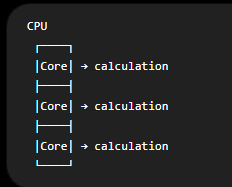

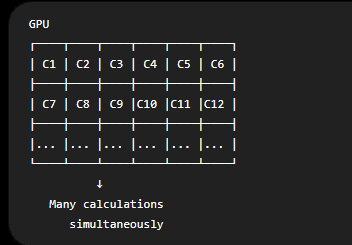

# Manipulating Tensor

 > Tensor manipulation means changing, accessing, combining, or rearranging tensor data without necessarily changing the underlying values.

## 1. Indexing

Access a specific element.

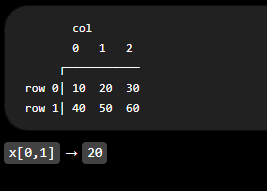

In [7]:
matrix1 = torch.tensor([
    [36,21,45],
    [12,9,55],
    [66,3,14]
])

matrix1

tensor([[36, 21, 45],
        [12,  9, 55],
        [66,  3, 14]])

In [9]:
print(matrix1[2,2])  #row,col

tensor(14)


## Slicing

Get a portion of a tensor.

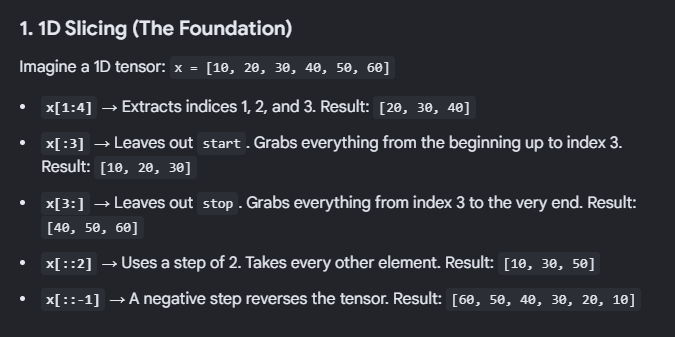

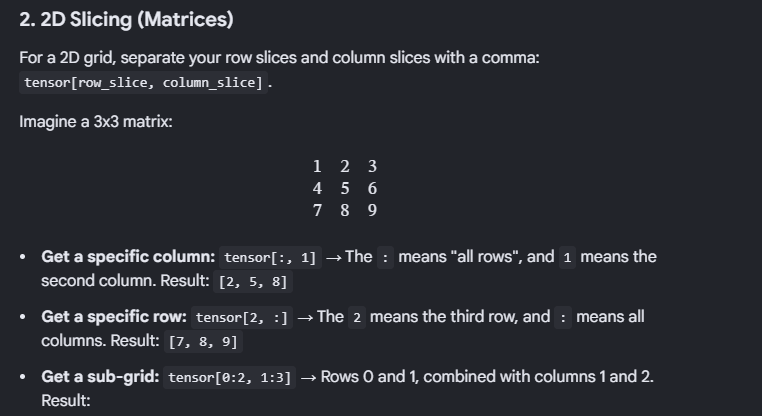

In [16]:
x = torch.randint(10,90,(4,5)) # row=4 , col=5
x

tensor([[44, 52, 74, 58, 34],
        [13, 40, 34, 86, 74],
        [19, 84, 47, 62, 30],
        [70, 74, 46, 70, 14]])

In [21]:
print(x[:2])

tensor([[44, 52, 74, 58, 34],
        [13, 40, 34, 86, 74]])


# Tensor operations

* Addition
* Subtraction
* Multiplication (element Wise )
* Division
* Matrix operation

## Addition

In [23]:
tensor = torch.tensor([1,2,3])
tensor + 10

tensor([11, 12, 13])

In [25]:
matrix1 = torch.randint(2,9,(3,4))
matrix2 = torch.randint(29,38,(3,4))

In [26]:
matrix1

tensor([[2, 6, 6, 6],
        [7, 2, 8, 2],
        [7, 8, 3, 8]])

In [27]:
matrix2

tensor([[34, 33, 31, 37],
        [30, 31, 33, 37],
        [34, 34, 33, 31]])

In [28]:
print(matrix1 + matrix2)

tensor([[36, 39, 37, 43],
        [37, 33, 41, 39],
        [41, 42, 36, 39]])


## Subtraction

In [29]:
tensor =  torch.tensor([20,45,13])

tensor-13

tensor([ 7, 32,  0])

In [30]:
print(matrix1-matrix2)

tensor([[-32, -27, -25, -31],
        [-23, -29, -25, -35],
        [-27, -26, -30, -23]])


## Multiplication

 > This is element-wise multiplication, not matrix multiplication.

In [40]:
matric1 = torch.randint(3,21,(3,4))
matric2 = torch.randint(17,29,(4,3))

In [41]:
D = torch.matmul(matric1,matric2)
D

tensor([[1352, 1223, 1482],
        [ 916,  791, 1046],
        [ 888,  783, 1038]])

In [42]:
C = matrix1 * matrix2

print(C)

tensor([[ 68, 198, 186, 222],
        [210,  62, 264,  74],
        [238, 272,  99, 248]])


## Transpose

In [43]:
A = torch.tensor([
    [1, 2, 3],
    [4, 5, 6]
])

print(A.T)

tensor([[1, 4],
        [2, 5],
        [3, 6]])


# Calculate operation time

In [44]:
C = matrix1 * matrix2

print(C)

tensor([[ 68, 198, 186, 222],
        [210,  62, 264,  74],
        [238, 272,  99, 248]])


In [45]:
%%time

value = 0

for i in range(len(C)):
  value += C[i] * C[i]

print(value)

tensor([105368, 117032, 114093, 116264])
CPU times: user 1.81 ms, sys: 3 µs, total: 1.81 ms
Wall time: 1.63 ms


 > With matmul(matrix1,matrix2)

In [47]:
D = torch.matmul(matric1,matric2)
D

tensor([[1352, 1223, 1482],
        [ 916,  791, 1046],
        [ 888,  783, 1038]])

In [48]:
%%time

value=0

for i in range(len(D)):
  value += D[i] * D[i]

print(value)

tensor([3455504, 2734499, 4367884])
CPU times: user 1.9 ms, sys: 0 ns, total: 1.9 ms
Wall time: 1.59 ms
